# Visualizing results

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [373]:
score_dir = "/home/lnishimw/scratch/experiments/evaluation-challenges/experiment_049/scores"
score_files = {
    corpus: f"{score_dir}/scores_{corpus}.csv" for corpus in ["rocsmt", "footweets", "mmtc", "pfsmb", "rocsmt-gpt", "footweets-gpt", "mmtc-gpt", "pfsmb-gpt"]
}

In [374]:
dfs = {corpus: pd.read_csv(score_files[corpus]) for corpus in score_files}

In [58]:
from llm.prompt_templates import GUIDELINES, LLAMA_MODEL_NAME, GEMMA_MODEL_NAME

In [18]:
NLLB_MODEL_NAME = "nllb-200-3.3B"

In [5]:
GUIDELINE_NAMES

['default', 'standard', 'general']

In [34]:
GUIDELINES = {
    "default": 0,
    "standard": 1,
    "general": 2,
}

In [176]:
MODELS = {
    NLLB_MODEL_NAME:{
        "name": "NLLB-3B",
        "id": "0",
    },
    LLAMA_MODEL_NAME:{
        "name": "LLaMa-3.1-8B",
        "id": "1",
    },
    GEMMA_MODEL_NAME:{
        "name": "Gemma-2-9B",
        "id": "2",
    }
}

In [205]:
CORPORA = {
    "rocsmt": {
        "name": "RoCS-MT",
        "id": "0",
        "refs": "raw"
    },
    "rocsmt-gpt": {
        "name": "RoCS-MT",
        "id": "1",
        "refs": "norm"
    },
    "footweets": {
        "name": "FooTweets",
        "id": "2",
        "refs": "raw"
    },
    "footweets-gpt": {
        "name": "FooTweets",
        "id": "3",
        "refs": "norm"
    },
    "mmtc": {
        "name": "MMTC",
        "id": "4",
        "refs": "raw"
    },
    "mmtc-gpt": {
        "name": "MMTC",
        "id": "5",
        "refs": "norm"
    },
    "pfsmb": {
        "name": "PFSMB",
        "id": "6",
        "refs": "raw"
    },
    "pfsmb-gpt": {
        "name": "PFSMB",
        "id": "7",
        "refs": "norm"
    }
}

In [206]:
def get_guidelines(filename):
    guideline = filename.split(".")[-2]
    if guideline not in GUIDELINE_NAMES:
        guideline = "default"
    return guideline

def get_model_names(model):
    return MODELS[model.split("/")[-1]]["name"]

def get_model_id(model):
    return MODELS[model.split("/")[-1]]["id"]

def get_guideline_id(guideline):
    return GUIDELINES[guideline]

def get_corpus_id(corpus):
    return CORPORA[corpus]["id"]

def get_corpus_name(corpus):
    return CORPORA[corpus]["name"]

def get_reference_type(corpus):
    return CORPORA[corpus]["refs"]

In [229]:
def normalize_error_counts(data):
    data["minor"] = data["minor"] / data["total"] * 100
    data["major"] = data["major"] / data["total"] * 100
    data["critical"] = data["critical"] / data["total"] * 100
    return data

In [375]:
all_data = pd.DataFrame()

for corpus in dfs:
    data = dfs[corpus].copy()
    data["guideline"] = data["file"].apply(get_guidelines)
    data["model_name"] = data["model"].apply(get_model_names)+ " (" + data["guideline"]  + ")"
    data["model_id"] = data["model"].apply(get_model_id)
    data["guideline_id"] = data["guideline"].apply(get_guideline_id)
    data["corpus"] = get_corpus_name(corpus)
    data["corpus_id"] = get_corpus_id(corpus)
    data["reference_type"] = get_reference_type(corpus)
    all_data = all_data.append(data)



/home/lnishimw/scratch/tmp/ipykernel_3393968/1414834282.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  all_data = all_data.append(data)
/home/lnishimw/scratch/tmp/ipykernel_3393968/1414834282.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  all_data = all_data.append(data)
/home/lnishimw/scratch/tmp/ipykernel_3393968/1414834282.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  all_data = all_data.append(data)
/home/lnishimw/scratch/tmp/ipykernel_3393968/1414834282.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  all_data = all_data.append(data)
/home/lnishimw/scratch/tmp/ipykernel_3393968/1414834282.py:12: FutureWarning

In [376]:
all_data = all_data.sort_values(["corpus_id", "model_id", "guideline_id", "reference_type"], ascending=[True, True, True, False])
all_data.head()

,model,file,bleu,chrf2,comet,xcomet,minor,major,critical,total,...,major_sents,critical_sents,correct_sents,guideline,model_name,model_id,guideline_id,corpus,corpus_id,reference_type
0,facebook/nllb-200-3.3B,raw.en.test.out,21.332086,43.825091,73.213880,77.169062,1230,2352,105,3687,...,983,84,363,default,NLLB-3B (default),0,0,RoCS-MT,0,raw
1,meta-llama/Llama-3.1-8B-Instruct,raw.en.test.default.out,20.161005,42.723988,74.026405,78.217072,1380,2499,76,3955,...,997,55,374,default,LLaMa-3.1-8B (default),1,0,RoCS-MT,0,raw
2,meta-llama/Llama-3.1-8B-Instruct,raw.en.test.standard.out,20.044900,42.703130,74.139383,78.247300,1364,2498,90,3952,...,981,62,381,standard,LLaMa-3.1-8B (standard),1,1,RoCS-MT,0,raw
3,meta-llama/Llama-3.1-8B-Instruct,raw.en.test.general.out,19.975092,42.499427,74.459183,78.732861,1398,2495,80,3973,...,980,59,337,general,LLaMa-3.1-8B (general),1,2,RoCS-MT,0,raw
4,google/gemma-2-9b-it,raw.en.test.default.out,23.571598,46.148452,76.827113,81.626830,1570,2198,62,3830,...,897,43,370,default,Gemma-2-9B (default),2,0,RoCS-MT,0,raw


In [292]:
def plot_scores(all_data, metrics, sharex=True, sharey=True):
    corpora = all_data["corpus"].unique()
    fig, axs = plt.subplots(len(corpora), len(metrics), figsize=(4*len(metrics), 3*len(corpora)), sharex=sharex, sharey=sharey)
    for i, corpus in enumerate(corpora):
        for j, metric in enumerate(metrics):
            data = all_data[all_data["corpus"] == corpus]
            sns.barplot(x=metric, y="model_name", hue="reference_type", ax=axs[i,j], data=data) #, vmin=0, vmax=100) , cmap="YlGnBu"
            axs[i,j].set_title(f"{corpus}")
            axs[i,j].set_ylabel("Model")
    plt.tight_layout()
    plt.show()


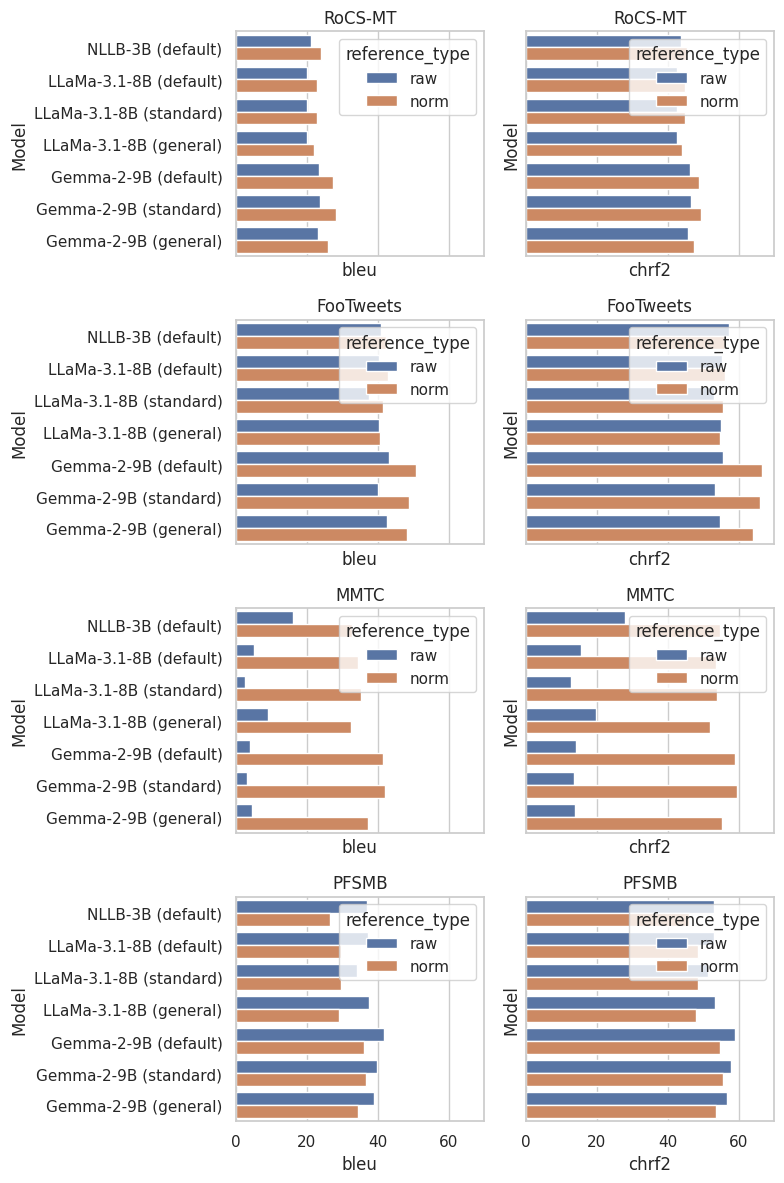

In [377]:
metrics = ["bleu", "chrf2"]
plot_scores(all_data, metrics)

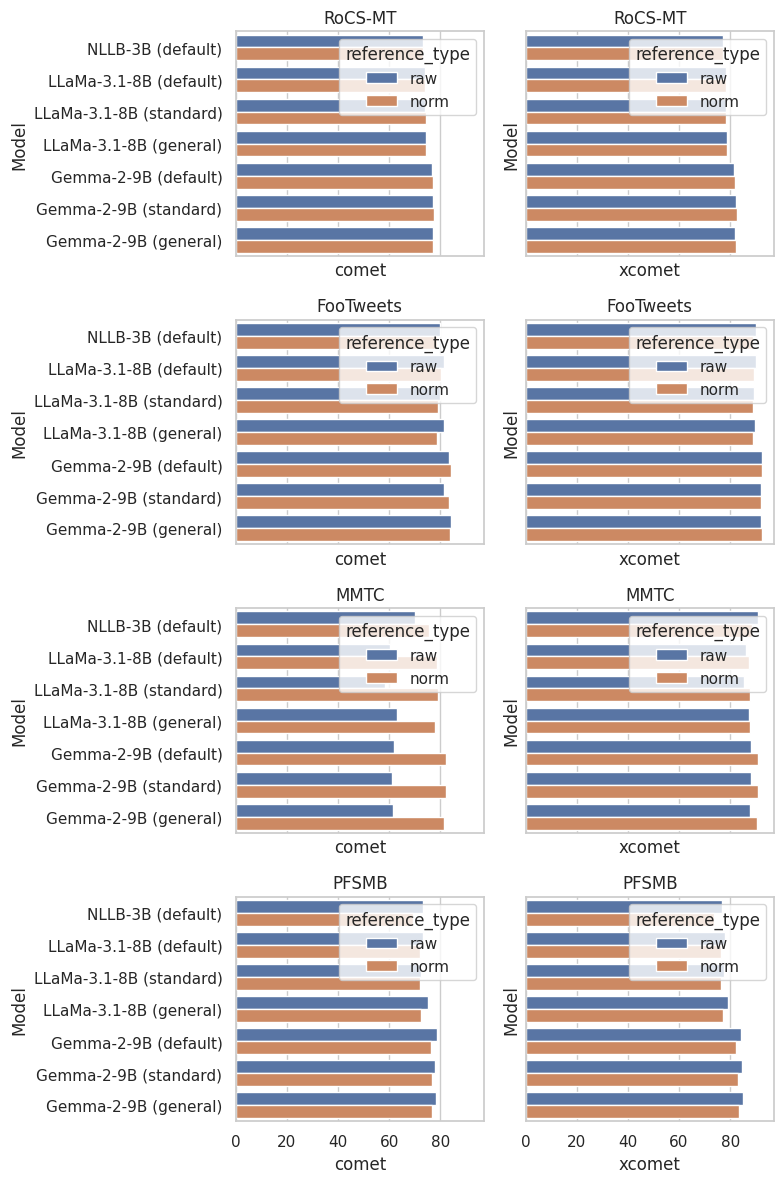

In [294]:
metrics = ["comet", "xcomet"]
plot_scores(all_data, metrics)

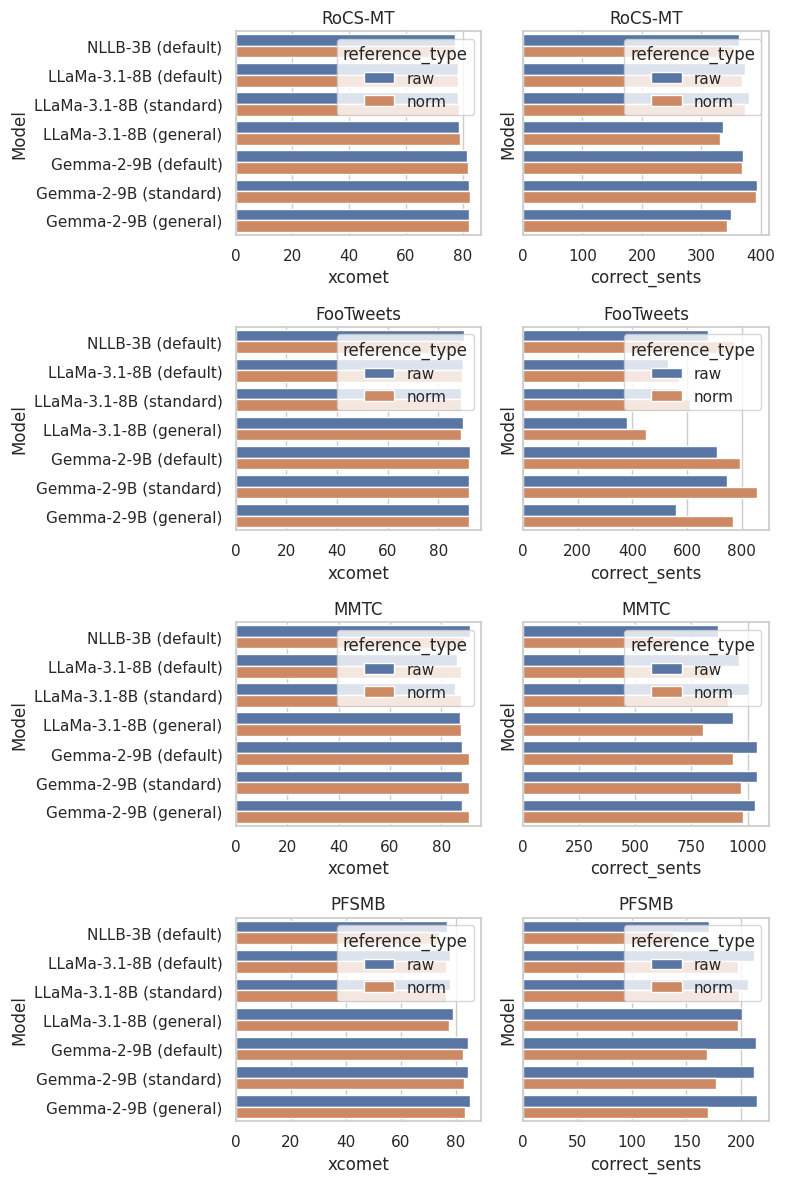

In [380]:
metrics = ["xcomet", "correct_sents"]
plot_scores(all_data, metrics, sharex=False)

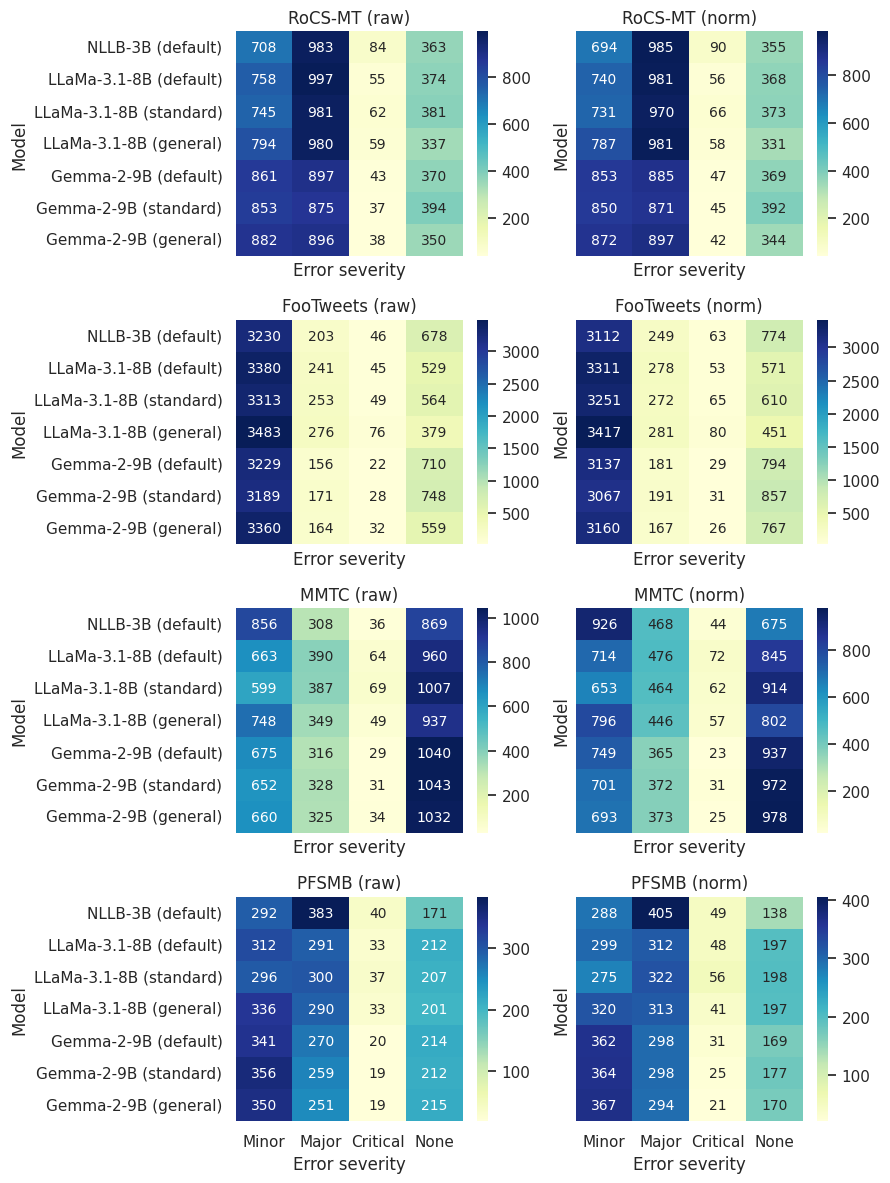

In [387]:
def plot_error_types(all_data):
    reference_types = all_data["reference_type"].unique()
    corpora = all_data["corpus"].unique()
    fig, axs = plt.subplots(len(corpora), len(reference_types), figsize=(4*len(reference_types)+1, 3*len(corpora)), sharey=True, sharex=True)
    for i, corpus in enumerate(corpora):
        for j, ref in enumerate(reference_types):
            data = all_data[(all_data["corpus"] == corpus) & (all_data["reference_type"] == ref)]
            data = data[["model_name", "minor_sents", "major_sents", "critical_sents", "correct_sents"]]
            sns.heatmap(data.set_index("model_name"), annot=True, fmt=".0f", cmap="YlGnBu", ax=axs[i,j]) #, vmin=0, vmax=100)
            axs[i,j].set_title(f"{corpus} ({ref})")
            axs[i,j].set_ylabel("Model")
            axs[i,j].set_xlabel("Error severity")
            axs[i,j].set_xticklabels(["Minor", "Major", "Critical", "None"], rotation=0)
            axs[i,j].set_yticklabels(data["model_name"].unique(), rotation=0)
            # reduce annotations font size
            for t in axs[i,j].texts:
                t.set_fontsize(10)
    plt.tight_layout()
    plt.show()

plot_error_types(all_data)

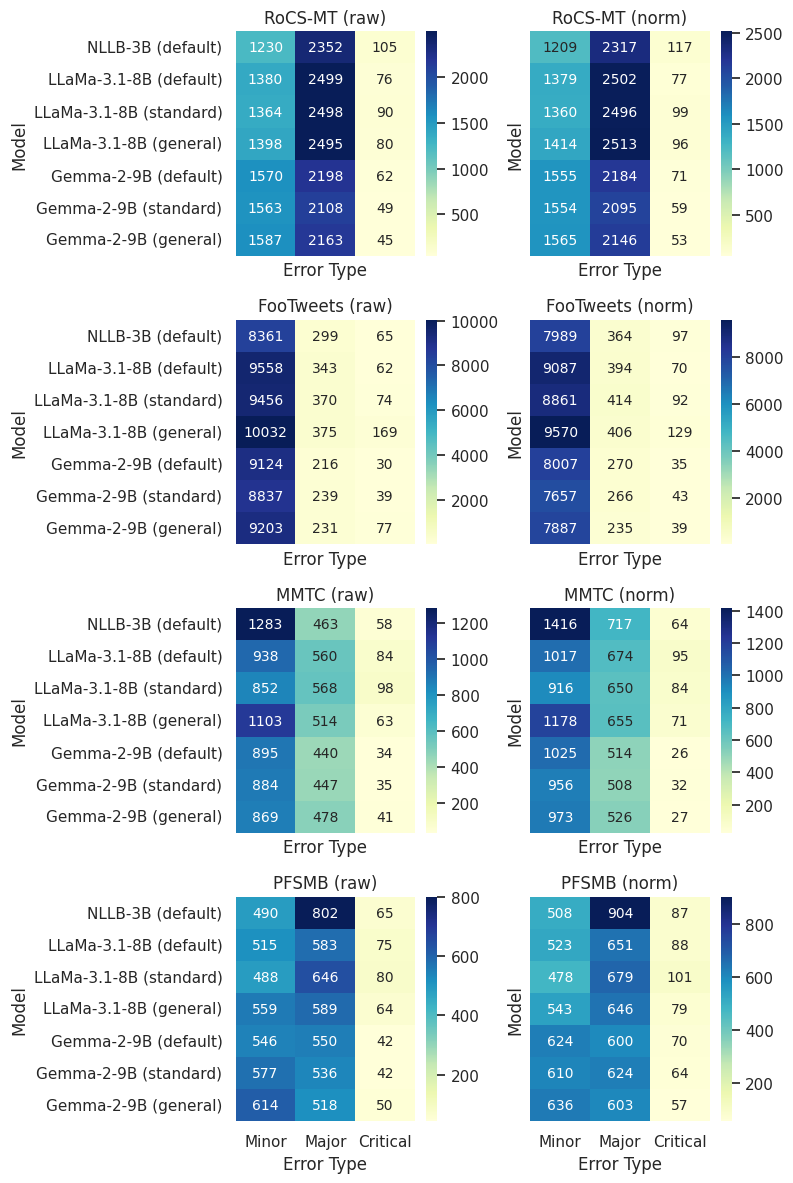

In [300]:
def plot_error_types(all_data):
    reference_types = all_data["reference_type"].unique()
    corpora = all_data["corpus"].unique()
    fig, axs = plt.subplots(len(corpora), len(reference_types), figsize=(4*len(reference_types), 3*len(corpora)), sharey=True, sharex=True)
    for i, corpus in enumerate(corpora):
        for j, ref in enumerate(reference_types):
            data = all_data[(all_data["corpus"] == corpus) & (all_data["reference_type"] == ref)]
            data = data[["model_name", "minor_sents", "major_sents", "critical_sents"]]
            sns.heatmap(data.set_index("model_name"), annot=True, fmt=".0f", cmap="YlGnBu", ax=axs[i,j]) #, vmin=0, vmax=100)
            axs[i,j].set_title(f"{corpus} ({ref})")
            axs[i,j].set_ylabel("Model")
            axs[i,j].set_xlabel("Error Type")
            axs[i,j].set_xticklabels(["Minor", "Major", "Critical"])
            axs[i,j].set_yticklabels(data["model_name"].unique(), rotation=0)
            # reduce annotations font size
            for t in axs[i,j].texts:
                t.set_fontsize(10)
    plt.tight_layout()
    plt.show()

plot_error_types(all_data)

# Analyzing error types

In [1]:
import json

In [19]:
def get_errors(errors, severity):
    sentence_ids = []
    for i, sentence in enumerate(errors):
        for span in sentence["spans"]:
            if span["severity"] == severity:
                sentence_ids.append(i)
                break
    return set(sentence_ids)

def get_correct(errors):
    sentence_ids = []
    for i, sentence in enumerate(errors):
        if len(sentence["spans"]) == 0:
            sentence_ids.append(i)
    return set(sentence_ids)

In [4]:
src_file = "/home/lnishimw/scratch/datasets/mmtc/test.fr-en.fr"
ref_file = "/home/lnishimw/scratch/datasets/mmtc/test.fr-en.en"
ref_file_norm = "/home/lnishimw/scratch/datasets/mmtc/gpt.test.fr-en.en"

def read_file(file):
    with open(file, "r") as f:
        #get lines without newline character
        return [line.strip() for line in f.readlines()]

src = read_file(src_file)
ref = read_file(ref_file)
ref_norm = read_file(ref_file_norm)


In [12]:
model = "google/gemma-2-9b-it"
guideline = "default."
sys_file = f"/home/lnishimw/scratch/experiments/evaluation-challenges/experiment_049/outputs/{model}/mmtc/test.fr-en.fr.{guideline}out"
error_file = f"/home/lnishimw/scratch/experiments/evaluation-challenges/experiment_049/outputs/{model}/mmtc/test.fr-en.fr.{guideline}out.errors.json"
error_file_norm = f"/home/lnishimw/scratch/experiments/evaluation-challenges/experiment_049/outputs/{model}/mmtc-gpt/test.fr-en.fr.{guideline}out.errors.json"

with open(error_file, "r") as f:
    errors = json.load(f)

with open(error_file_norm, "r") as f:
    errors_norm = json.load(f)

sys = read_file(sys_file)

In [13]:
critical_errors = get_errors(errors, "critical")
critical_errors_norm = get_errors(errors_norm, "critical")

major_errors = get_errors(errors, "major")
major_errors_norm = get_errors(errors_norm, "major")

minor_errors = get_errors(errors, "minor")
minor_errors_norm = get_errors(errors_norm, "minor")

In [14]:
all_errors = critical_errors.union(major_errors).union(minor_errors)
all_errors_norm = critical_errors_norm.union(major_errors_norm).union(minor_errors_norm)

In [15]:
no_errors = get_correct(errors)
no_errors_norm = get_correct(errors_norm)

In [16]:
print("raw", "gpt")
print(len(critical_errors), len(critical_errors_norm))
print(len(major_errors), len(major_errors_norm))
print(len(minor_errors), len(minor_errors_norm))
print(len(all_errors), len(all_errors_norm))
print(len(no_errors), len(no_errors_norm))


raw gpt
29 23
316 365
675 749
960 1063
1040 937


In [17]:
# get intersection of critical errors
intersection = critical_errors.intersection(all_errors)
print(len(intersection))

29


In [18]:
for i in critical_errors:
    print("Line", (i+1))
    print("SRC:", src[i])
    print("SYS:", sys[i])
    print("REF (raw):", ref[i])
    print("ERRORS (raw):", errors[i])
    print("REF (gpt):", ref_norm[i])
    print("ERRORS (gpt):", errors_norm[i])
    print()

Line 387
SRC: @Ludo_Perverie Déjà fait l'an dernier
SYS: Already did it last year.
REF (raw): @Ludo_Perverie Already done last year
ERRORS (raw): {'score': 0.6809611320495605, 'spans': [{'text': 'Already did', 'confidence': 0.38789039850234985, 'severity': 'critical', 'start': 0, 'end': 11}]}
REF (gpt): Already done last year.
ERRORS (gpt): {'score': 0.9078869223594666, 'spans': [{'text': 'did', 'confidence': 0.3566102385520935, 'severity': 'minor', 'start': 7, 'end': 11}]}

Line 1667
SRC: RT @abracadaspliff: qui s'absente, ce fait oublier et aussitôt remplacé
SYS: Out of sight, out of mind and quickly replaced.
REF (raw): RT @abracadaspliff: he who is away, is forgotten and immediately replaced
ERRORS (raw): {'score': 0.4102344214916229, 'spans': [{'text': 'Out of sight, out of mind', 'confidence': 0.6553688049316406, 'severity': 'critical', 'start': 0, 'end': 25}]}
REF (gpt): He who is away is forgotten and immediately replaced.
ERRORS (gpt): {'score': 0.6081463098526001, 'spans': [{

# Qualitative Analysis

## Selected examples

In [2]:
import json, yaml, os

In [3]:
corpus = "rocsmt"
rocsmt_line_numbers = [9,11,18,36,43,51,56,80,91,97,102,120,153,160,164,180,220,248,264,283,319,347,369,416,478,536,574,593,624,633,655,666,750,780,805,807,817,838,904,906,907,922,930,951,976,980,996,1015,1034,1047,1134,1153,1193,1205,1207,1230,1275,1311,1436,1462,1468,1482,1537,1548,1593,1596,1643,1648,1665,1739,1768,1780,1803,1922]
rocsmt_lines_ids = [k - 1 for k in rocsmt_line_numbers]

In [4]:
corpus = "footweets"
footweets_line_numbers = [2,3,7,18,21,22,24,26,30,35,177,195,337,374,414,422,525,536,573,610,637,707,718,914,1011,1093,1097,1350,1566,1567,1568,1569,1571,1612,1817,1992,2148,2420,2444,2525,2526,2544,2548,2590,2669,2670,2692,2813,2853,2885,2953,3354,3490,3566,3799,3910,3933,3986]
footweets_lines_ids = [k - 1 for k in footweets_line_numbers]

In [5]:
corpus = "mmtc"
mmtc_line_numbers = [1, 6, 8, 82, 96, 131, 188, 289, 301, 332, 441, 457, 610, 621, 667, 792, 801, 891, 976, 1008, 1035, 1179, 1262, 1465, 1522, 1627, 1643, 1667, 1712, 1746, 1763, 1774, 1782, 1862, 1898, 1935, 1963, 1999] 
mmtc_lines_ids = [k - 1 for k in mmtc_line_numbers]

In [6]:
corpus = "pfsmb"
pfsmb_line_numbers = [3,27,32,34,35,45,46,63,78,105,117,119,122,129,152,166,173,186,204,298,303,306,421,427,438,467,471,503,523,640,656,657,669,687,688,731,744,770]
pfsmb_lines_ids = [k - 1 for k in pfsmb_line_numbers]

In [7]:
corpora_config_file = "/home/lnishimw/evaluation-challenges/src/llm/config/corpora.yaml"
with open(corpora_config_file, "r") as f:
    corpora_config = yaml.safe_load(f)

In [9]:
corpora_config

{'rocsmt': {'src_file_path': '$DATASETS/rocsmt/test/raw.en.test',
  'ref_file_path': '$DATASETS/rocsmt/test/ref.fr.test'},
 'footweets': {'src_file_path': '$DATASETS/footweets/detok.twitter.sent.en.txt',
  'ref_file_path': '$DATASETS/footweets/detok.twitter.sent.de.txt'},
 'mmtc': {'src_file_path': '$DATASETS/mmtc/test.fr-en.fr',
  'ref_file_path': '$DATASETS/mmtc/test.fr-en.en'},
 'pfsmb': {'src_file_path': '$DATASETS/pfsmb/test.fr',
  'ref_file_path': '$DATASETS/pfsmb/test.en'},
 'rocsmt-gpt': {'src_file_path': '$DATASETS/rocsmt/test/raw.en.test',
  'ref_file_path': '$DATASETS/rocsmt/test/gpt.ref.fr.test'},
 'footweets-gpt': {'src_file_path': '$DATASETS/footweets/detok.twitter.sent.en.txt',
  'ref_file_path': '$DATASETS/footweets/gpt.detok.twitter.sent.de.txt'},
 'mmtc-gpt': {'src_file_path': '$DATASETS/mmtc/test.fr-en.fr',
  'ref_file_path': '$DATASETS/mmtc/gpt.test.fr-en.en'},
 'pfsmb-gpt': {'src_file_path': '$DATASETS/pfsmb/test.fr',
  'ref_file_path': '$DATASETS/pfsmb/gpt.test.en

In [10]:
analysis_lines = {
    "rocsmt": rocsmt_lines_ids,
    "footweets": footweets_lines_ids,
    "mmtc": mmtc_lines_ids,
    "pfsmb": pfsmb_lines_ids,
}

In [11]:
def read_file(file):
    with open(file, "r") as f:
        #get lines without newline character
        return [line.strip() for line in f.readlines()]
    
def read_json(file):
    with open(file, "r") as f:
        return json.load(f)


In [12]:
NLLB = "facebook/nllb-200-3.3B"


In [28]:
corpus = "rocsmt"
model = "google/gemma-2-9b-it"
experiment_dir = "/home/lnishimw/scratch/experiments/evaluation-challenges/experiment_049/"
guidelines = ["baseline", "default", "general"]

src_file = os.path.expandvars(corpora_config[corpus]["src_file_path"])
ref_file = os.path.expandvars(corpora_config[corpus]["ref_file_path"])
src_file_name = os.path.basename(src_file)
src = read_file(src_file)
ref = read_file(ref_file)

sys = {}
errors = {}
for guideline in guidelines:
    sys_model = NLLB if (guideline == "baseline") else model
    guideline_ext = "out" if (guideline == "baseline") else  f"{guideline}.out"
    sys_file = f"{experiment_dir}/outputs/{sys_model}/{corpus}/{src_file_name}.{guideline_ext}"
    error_file = f"{experiment_dir}/outputs/{sys_model}/{corpus}/{src_file_name}.{guideline_ext}.errors.json"
    errors[guideline] = read_json(error_file)
    sys[guideline] = read_file(sys_file)




In [29]:
errors.keys()

dict_keys(['baseline', 'default', 'general'])

In [30]:
def get_outputs(line_ids, src, ref, sys, errors):
    output = ""
    for i in line_ids:
        output += f"Line {i+1}\n"
        output += f"SRC: {src[i]}\n"
        output += f"REF: {ref[i]}\n"
        for guideline in sys:
            output += f"SYS ({guideline}): {sys[guideline][i]}\n"
            output += f"ERRORS ({guideline}): {errors[guideline][i]}\n"
        output += "\n"
    return output

In [31]:
print(get_outputs(analysis_lines[corpus], src, ref, sys, errors))

Line 9
SRC: Me: probs my friend's hotel room/wherever he can find a place for it
REF: Moi : Sûrement dans la chambre d’hôtel de mon pote, ou là où il lui aura trouvé de la place.
SYS (baseline): Moi: sonde la chambre d'hôtel de mon ami/où il peut trouver un endroit pour ça
ERRORS (baseline): {'score': 0.696578323841095, 'spans': [{'text': ': sonde la', 'confidence': 0.4335190951824188, 'severity': 'major', 'start': 3, 'end': 13}, {'text': "d'", 'confidence': 0.38314899802207947, 'severity': 'major', 'start': 21, 'end': 24}, {'text': 'ami/où il peut trouver un endroit pour ça', 'confidence': 0.40623846650123596, 'severity': 'major', 'start': 36, 'end': 78}]}
SYS (default): Peut-être la chambre d'hôtel de mon ami/où qu'il puisse trouver une place.
ERRORS (default): {'score': 0.7534622550010681, 'spans': [{'text': 'être la', 'confidence': 0.33782023191452026, 'severity': 'major', 'start': 5, 'end': 12}, {'text': "'", 'confidence': 0.3629778325557709, 'severity': 'minor', 'start': 22, 'end

## Critical errors

In [32]:
critical_errors = {}
for guideline in errors:
    critical_errors[guideline] = get_errors(errors[guideline], "critical")

In [33]:
critical_errors["all"] = set()
for guideline in critical_errors:
    print(guideline, len(critical_errors[guideline]))
    critical_errors["all"] = critical_errors["all"].union(critical_errors[guideline])


baseline 84
default 43
general 38
all 129


In [34]:
print(get_outputs(critical_errors["all"], src, ref, sys, errors))

Line 4
SRC: We're both xxx majors (I'm a dual xxx and yyy major while she's a xxx major and yyy minor, so we are taking 2-3 classes together every semester until graduation in May 2018).
REF: On est toutes les deux en xxx (j’ai choisi double dominante (xxx et yyy), et elle dominante xxx et mineure yyy, alors tous les semestres, jusqu’à la fin du cursus en mai 2018, on a 2 ou 3 cours en commun).
SYS (baseline): Nous sommes tous les deux des étudiants de XXXX (je suis un double étudiant de XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX